### Imports and Configuration

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

### Load Ground Truth & Prepare Labels

In [6]:
# Load expert rating summary
df = pd.read_csv("../data/procdata/2_drugSensitivity/expert_rating/expert_rating_summary.csv")

# Filter for consistent ratings (only those without "/")
df_clean = df[~df['rating_merge'].str.contains('/', na=False)].copy()

# Map categories to integers (0-4)
cat_map = {f'cat{i}': i-1 for i in range(1, 6)}
df_clean['label'] = df_clean['rating_merge'].map(cat_map)

# load in statistics from xeva
stats_df = pd.read_csv("../data/rawdata/pdxe/xeva_sensitivity/manifest.csv")
stats_df = stats_df.drop(columns=["batch_id","model_id","image_file"])

# Merge into one dataset
df_clean = df_clean.merge(stats_df, on="figure_id", how="left")
df_clean

,figure_id,rating_guanqiao,rating_mitchell,rating_samah,rating_merge,label,model_mRECIST,model_best.response,model_best.response.time,model_best.average.response,model_best.average.response.time,model_AUC,model_slope,batch_slope.control,batch_slope.treatment,batch_angle,batch_auc.control,batch_auc.treatment,batch_abc,batch_TGI
0,fig_000001,cat3,cat3,cat3,cat3,2,SD,24.003504,16,26.511170,10,307.260000,76.333700,87.447147,76.333700,11.113447,510.728571,307.260000,203.468571,35.669683
1,fig_000002,cat1,cat3,cat1,cat1,0,PD,228.400868,10,88.214544,10,671.310714,89.127445,82.182183,89.127445,-6.945262,303.975000,671.310714,-367.335714,39.576923
2,fig_000003,cat2,cat2,cat1,cat2,1,PD,73.716730,10,38.902091,10,642.380208,87.205563,88.067578,86.136778,1.930801,647.595455,442.018333,205.577121,27.400000
3,fig_000004,cat5,cat4,cat5,cat5,4,CR,-100.000000,30,-50.081699,66,196.739032,15.192136,88.067578,-74.343153,162.410732,647.595455,199.568333,448.027121,62.963235
4,fig_000005,cat4,cat5,cat4,cat4,3,PR,-82.740879,30,-55.599966,37,221.755714,53.299400,86.385796,-56.780070,143.165866,712.692958,120.874286,591.818672,-97.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,fig_001296,cat2,cat2,cat2,cat2,1,PD,60.509820,11,15.305056,11,493.019643,87.421848,89.037513,85.366462,3.671051,609.539286,299.646429,309.892857,-51.240602
1263,fig_001297,cat2,cat2,cat2,cat2,1,PD,178.595318,11,93.237876,11,617.073684,88.544554,89.037513,88.549140,0.488373,609.539286,520.992857,88.546429,-26.856061
1264,fig_001298,cat1,cat1,cat1,cat1,0,PD,306.707566,11,145.398773,11,718.896429,89.211139,89.037513,89.211139,-0.173626,609.539286,718.896429,-109.357143,11.459459
1265,fig_001299,cat3,cat3,cat3,cat3,2,SD,12.900395,19,6.757350,11,407.419737,85.211292,89.037513,72.455824,16.581689,609.539286,247.628571,361.910714,-459.947368


### Identify NA

In [7]:
na_counts = df_clean.isnull().sum()

print(na_counts[na_counts > 0])

rating_mitchell    1
rating_samah       7
dtype: int64


### Convert categorical variable for mRECIST

In [10]:
mrecist_map = {
    'CR': 0, # Complete Response
    'PR': 1, # Partial Response
    'SD': 2, # Stable Disease
    'PD': 3  # Progressive Disease
}

df_clean['model_mRECIST_encoded'] = df_clean['model_mRECIST'].map(mrecist_map)

### identify inf

In [ ]:
# Create the numeric subset first
df_numeric = df_clean.select_dtypes(include=[np.number])

# Find which of THESE columns have Inf
cols_with_inf = df_numeric.columns[np.isinf(df_numeric).any()].tolist()

print(f"Columns with Inf: {cols_with_inf}")

Columns with Inf: ['batch_TGI']


### Replace inf with max; -inf with min

In [ ]:
finite_max = df_clean.loc[np.isfinite(df_clean['batch_TGI']), 'batch_TGI'].max()
finite_min = df_clean.loc[np.isfinite(df_clean['batch_TGI']), 'batch_TGI'].min()

df_clean['batch_TGI'] = df_clean['batch_TGI'].replace(np.inf, finite_max)
df_clean['batch_TGI'] = df_clean['batch_TGI'].replace(-np.inf, finite_min)

print(f"Replaced Inf with: {finite_max}")
print(f"Replaced -Inf with: {finite_min}")

Replaced Inf with: 3803.50000000022
Replaced -Inf with: -12301.0000000007


### Finalize dataframe, define features and target

In [13]:
df_final = df_clean

# Define the features (independent variables)
features = [
    'model_mRECIST_encoded', 'model_best.response', 'model_best.response.time', 
    'model_best.average.response', 'model_best.average.response.time', 
    'model_AUC', 'model_slope', 'batch_slope.control', 
    'batch_slope.treatment', 'batch_angle', 'batch_auc.control', 
    'batch_auc.treatment', 'batch_abc', 'batch_TGI'
]

# Define the target (dependent variable)
target = 'label'

### Train test split

In [14]:
X = df_final[features]
y = df_final[target]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

Train size: 1013, Test size: 254


### RF model training with grid search

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), 
                           param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


### Evaluate performance

Overall Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        61
           1       0.84      0.92      0.87        72
           2       0.88      0.75      0.81        60
           3       0.67      0.88      0.76        43
           4       1.00      0.56      0.71        18

    accuracy                           0.83       254
   macro avg       0.86      0.79      0.81       254
weighted avg       0.85      0.83      0.83       254



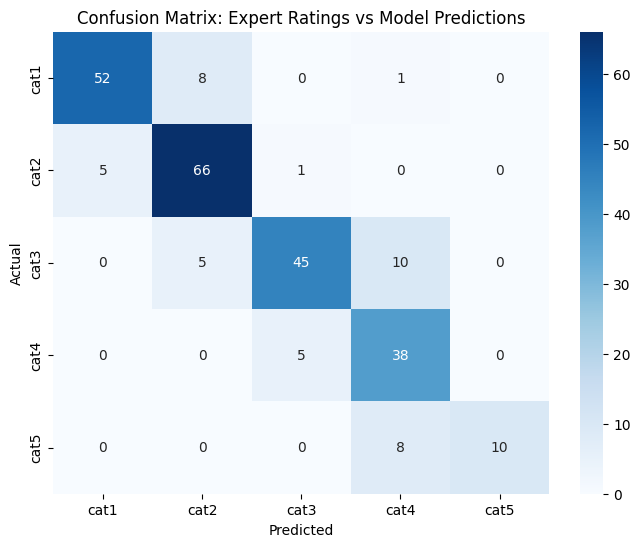

In [18]:
# Make predictions
y_pred = best_rf.predict(X_test)

# 1. Print Accuracy
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# 2. Detailed Report (Precision, Recall, F1-score for each cat)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'cat{i}' for i in range(1,6)], 
            yticklabels=[f'cat{i}' for i in range(1,6)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Expert Ratings vs Model Predictions')
plt.show()

### Feature importance

/var/folders/cz/vb9sgz_s0050f8rq5mdgr_hc0000gn/T/ipykernel_75438/1761507398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


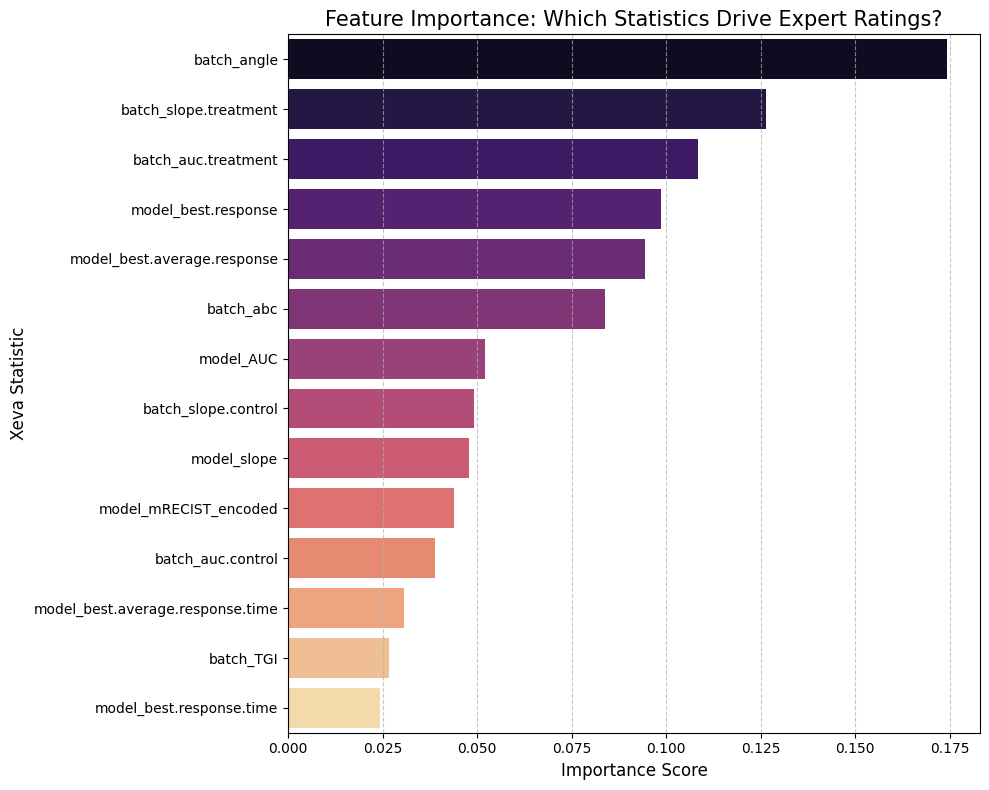

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importance and pair with feature names
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort for plotting
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance: Which Statistics Drive Expert Ratings?', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Xeva Statistic', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Prediction for new data

In [21]:
import joblib
import json

# 1. Save the model separately (Binary)
joblib.dump(best_rf, "../data/procdata/2_drugSensitivity/ml_model/random_forest/best_rf.joblib")

# 2. Save the text metadata separately (JSON)
metadata = {
    'features': list(X.columns),
    'mrecist_mapping': { 'CR': 0, 'PR': 1, 'SD': 2, 'PD': 3 },
    'label_mapping': {0: 'cat1', 1: 'cat2', 2: 'cat3', 3: 'cat4', 4: 'cat5'}
}

with open("../data/procdata/2_drugSensitivity/ml_model/random_forest/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

model_data = {
    'model': best_rf,
    'features': list(X.columns),
    'mrecist_mapping': { 'CR': 0, 'PR': 1, 'SD': 2, 'PD': 3 },
    'label_mapping': {0: 'cat1', 1: 'cat2', 2: 'cat3', 3: 'cat4', 4: 'cat5'}
}

# Save everything into one binary file
joblib.dump(model_data, "../data/procdata/2_drugSensitivity/ml_model/random_forest/rf_complete_package.joblib")

print("Model and metadata saved successfully.")

Model and metadata saved successfully.


## Prediction for new input

In [ ]:
import pandas as pd
import joblib

# 1. Load the complete package
package_path = "../data/procdata/2_drugSensitivity/ml_model/random_forest/rf_complete_package.joblib"
data_package = joblib.load(package_path)

# Extract components
model = data_package['model']
required_features = data_package['features']
mrecist_map = data_package['mrecist_mapping']
label_map = data_package['label_mapping']

# 2. Prepare your new input data
# Assuming 'new_data' is a DataFrame containing the Xeva statistics
# Example: new_data = pd.read_csv("path_to_new_samples.csv")

def predict_expert_cat(new_df):
    df = new_df.copy()
    
    # Map mRECIST to integers (handle missing or unexpected labels)
    if 'model_mRECIST' in df.columns:
        df['model_mRECIST_encoded'] = df['model_mRECIST'].map(mrecist_map).fillna(-1)
    
    # Ensure all required features exist (fill with 0 or median if missing)
    for col in required_features:
        if col not in df.columns:
            df[col] = 0 
            
    # Reorder columns to match exactly what the model saw during training
    X_new = df[required_features]
    
    # Handle any potential Infs in the new data (Clamping)
    import numpy as np
    X_new = X_new.replace([np.inf, -np.inf], np.nan)
    X_new = X_new.fillna(X_new.median()) # Use median of the NEW batch
    
    # 3. Perform Prediction
    predictions_int = model.predict(X_new)
    probabilities = model.predict_proba(X_new)
    
    # 4. Map back to 'cat1', 'cat2', etc.
    # Convert string keys in label_map to int if necessary
    # (Sometimes JSON/Joblib saves keys as strings)
    clean_label_map = {int(k): v for k, v in label_map.items()}
    final_labels = [clean_label_map[p] for p in predictions_int]
    
    return final_labels, probabilities

##--- USAGE ---
new_data = pd.DataFrame("../data/rawdata/pdxe/test/new_sample.xlsx")
labels, probs = predict_expert_cat(new_data)
new_data['predicted_rating'] = labels
print(new_data[['figure_id', 'predicted_rating']].head())